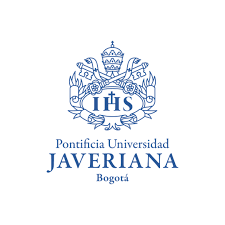
***Pontificia Universidad Javeriana***
# **Procesamiento de Alto Volumen de Datos**

### Taller: **Tratamiento de Datos y Machine Learning con PySpark**

Autor: Andres Jacobo Urrea
 
Fecha de Inicio: 16/04/2026 

Fecha actual: 27/04/2026

## **Problemática**

Se tiene que el tratamiento del agua debe ser indispensable para garantizar la pureza y la calidad. Uno de los elementos significativos es aplicar los conceptos de los Procesamientos de Datos en Alto Volúmen para solucionar este tipo de problemas que afectan la salud publica. El presente ejemplo tiene como propósito tener en cuenta una metodogología para aplicar el PAVD para solucionar o diagnósticar la calidad del agua en la INDIA.

## **Objetivo**

Implementar modelos de predicción utilizando la biblioteca de aprendizaje automático MLlib PySpark, con el fin de explorar y aplicar técnicas de IA en entornos de procesamiento con alto volúmen de datos.


## **Metodología**

1.- Importación de los datos (datos en diferentes formatos)

2.- Preprocesamiento y limpieza de valores nulos, cambio de datos, EDA, medidas estadísticas.

3.- Entrenamiento de modelos: RL (MLlib), tensores (KERAS); la idea es predecir la calidad del agua en la INDIA.

4.- Evaluación de los modelos: medidas de rendimiento tales como: precisión (precision), exactitud (accuracy), recall, F1 Score,entre otras.

5.- Se tiene como referencia de la calidad de los parámetros del agua, la referencia: https://www.intechopen.com/chapters/69568

## **1.- Importación de bibliotecas**

In [1]:
# Levantamiento de variables de entorno pip
import os #Permite interactuar con el sistema operativo
import sys #Permite configurar el intérprete de Python

sys.path.append('/usr/lib/python3/dist-packages/') # localiza la instalación de Apache Spark

import numpy as np #Permite realizar cálculos númericos y manejar vectores

import pandas as pd #Permite manipular tablas de datos (DataFrames) en la memoria de tu computadora

import seaborn as sns #Creación de gráficos estadísticos 

import matplotlib.pyplot as plt #Personalizar formatos de gráficas

from pylab import *    #Módulo que combina funciones de NumPy y Matplotlib

In [2]:
# **APACHE SPARK**
import findspark 

findspark.init() #

import pyspark.sql.functions as F #Contiene cientos de funciones listas para procesar columnas

from pyspark import SparkConf, SparkContext #Configuración técnica y de la conexión de bajo nivel con el clúster de Spark

from pyspark.sql import SQLContext #Contiene cientos de funciones listas para procesar columnas

from pyspark.sql import SparkSession #Permite crear DataFrames y ejecutar consultas SQL

from pyspark.sql.types import * #Definición de los tipos de datos de las columnas

In [3]:
### Levantamiento de sesión SPARK
# 1. Configuración inicial de la aplicación Spark
# Se asigna un nombre para identificar el proceso en el clúster
configura = SparkConf()
configura.setAppName("Calidad_Agua_Urrea")

# 2. Creación de la SparkSession
sparkS = SparkSession.builder.config(conf=configura).getOrCreate()

# 3. Soporte para SQL y Contexto
SQLContext(sparkContext=sparkS.sparkContext, sparkSession=sparkS)

# 4. Obtención del SparkContext
sparkContextoS = sparkS.sparkContext.getOrCreate()

# 5. Confirmación de inicio
print("Sesion creada: ProcesamientoDatos04")

sparkS

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/23 11:03:03 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Sesion creada: ProcesamientoDatos04


## **2.- Carga de Datos desde el HADOOP HDFS**


In [4]:
# Lee el archivo waterquality.csv asumiendo que está en el directorio actual.
# Usa formato CSV, con cabecera e infiere tipos automáticamente.
df00 = sparkS.read.format("csv").option("header", "true").load("waterquality.csv")
# Muestra las primeras 5 filas para verificar la carga
df00.show(5)


[Stage 1:>                                                          (0 + 1) / 1]

+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+--------------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+--------------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|         735|3.4|                  2|             3|            73|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|  6|  8|         270|3.1|                  2|            72|           182|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|         355|4.2|                  9|            59|           133|
|        2179|GODAVARI RIVER AT...|MAHARASHTRA|24.8|5.5|7.8|         371|5.6|               3.55|            90|           283|
|        2183|GODAVARI RIVER AT...|MAHARASHTRA|25.7|5.7|7.9|         294|3.2|               2.69|       

## **3.- Análisis y Preparación de Datos**

Se presentan datos (csv) con los diferentes parámetros de los rios de la India. Cada parámetro es el promedio de los valores medidos en un período de tiempo. Los datos han sido extraidos de la web oficial de la India (RiverIndia)

- Tipos de datos: coherencia de tipo de datos, transformación
- Columnas: conocimiento de las columnas, eliminación.
- Análisis de datos nulos o imposibles: concimiento.

In [5]:
##Conocimiento de las columnas
df00.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'TOTAL_COLIFORM']

In [6]:
# Lista de nombres originales 
NomOriginal = ['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'TOTAL_COLIFORM']
# Lista de nombres nuevos
NomNueva = ['CODIGO',
 'UBICACIONES',
 'ESTADO',
 'TEMPERATURA',
 'OXYGENO',
 'pH',
 'CONDUCTIVIDAD',
 'BOD',
 'NITROGENO',
 'BACTERIAS_COLIFORMES',
 'TOTAL_COLIFORMES']

# Copia del DataFrame original para no modificar df00 directamente 
df01 = df00
# Aplica el renombrado columna por columna recorriendo ambas listas simultáneamente
for antes, nuevo in zip(NomOriginal, NomNueva):
    df01 = df01.withColumnRenamed(antes, nuevo)
    
# Verifica que los nuevos nombres se hayan aplicado correctamente
df01.columns

['CODIGO',
 'UBICACIONES',
 'ESTADO',
 'TEMPERATURA',
 'OXYGENO',
 'pH',
 'CONDUCTIVIDAD',
 'BOD',
 'NITROGENO',
 'BACTERIAS_COLIFORMES',
 'TOTAL_COLIFORMES']

- STATION CODE: Código de estación de medida
- LOCATIONS: ubicaciones de los rios
- STATE: Estado de la india
- TEMP: Temperatura del agua en °C
- DO: Oxigeno Disuelto (mg/L). Concentraciones altas de oxigeno representa mejor calidad del agua.
- pH: Logaritmo negativo de la concentración de hidrógeno. Número adimensional para indicar la acidez del agua.
- CONDUCTIVITY: Mide la habilidad de una solución conducir corriente. El agua pura NO es conductora de corriente.
- BOD: Bacterias y otros microorganismos que utilizan sustancias orgánicas como alimento: Demanda Bioquímica de Oxigeno. Mayor cantidad de material orgánico mayor BOD.
- NITRATE_N_NITRITE_N: Nitratos/Nitritos "nitrógeno". Altas concentraciones Nitrogeno en la superficie del agua puede estimular el rápido crecimiento de algas las cuales degradan la calidad del agua (mg/L).
- FECAL_COLIFORM: Promedio de bacterias coliformes: excresiones.
- TOTAL_COLIFORM']: Se eliminará pues no aporta al estudio de predicción de la calidad del agua.

**Se presenta las estadísticas de los datos a continuación:**

In [7]:
# Itera sobre cada columna del DataFrame renombrado y muestra:
# Para columnas no numéricas, describe devuelve solo count, unique, top, freq
for valor in df01.columns:
  
  df01.describe([valor]).show()

+-------+-----------------+
|summary|           CODIGO|
+-------+-----------------+
|  count|              534|
|   mean|2052.516853932584|
| stddev|755.2178560086894|
|    min|             1023|
|    max|               41|
+-------+-----------------+



+-------+-------------------+
|summary|        UBICACIONES|
+-------+-------------------+
|  count|                534|
|   mean|               NULL|
| stddev|               NULL|
|    min|          AHMEDABAD|
|    max|ZUARI AT PANCHAWADI|
+-------+-------------------+

+-------+--------------+
|summary|        ESTADO|
+-------+--------------+
|  count|           534|
|   mean|          NULL|
| stddev|          NULL|
|    min|ANDHRA PRADESH|
|    max|   WEST BENGAL|
+-------+--------------+

+-------+------------------+
|summary|       TEMPERATURA|
+-------+------------------+
|  count|               534|
|   mean|25.241398865784515|
| stddev|3.4480130875026624|
|    min|              10.5|
|    max|                NA|
+-------+------------------+

+-------+-----------------+
|summary|          OXYGENO|
+-------+-----------------+
|  count|              534|
|   mean|6.389812030075193|
| stddev|1.622861728733986|
|    min|                0|
|    max|               NA|
+-------+--------

26/04/23 11:04:15 ERROR TransportClient: Failed to send RPC RPC 7395865619784308079 to /10.43.97.179:51748: io.netty.channel.StacklessClosedChannelException
io.netty.channel.StacklessClosedChannelException
	at io.netty.channel.AbstractChannel$AbstractUnsafe.write(Object, ChannelPromise)(Unknown Source)
26/04/23 11:04:15 WARN BlockManagerMasterEndpoint: Error trying to remove broadcast 11 from block manager BlockManagerId(1, 10.43.97.179, 46531, None)
java.io.IOException: Failed to send RPC RPC 7395865619784308079 to /10.43.97.179:51748: io.netty.channel.StacklessClosedChannelException
	at org.apache.spark.network.client.TransportClient$RpcChannelListener.handleFailure(TransportClient.java:395)
	at org.apache.spark.network.client.TransportClient$StdChannelListener.operationComplete(TransportClient.java:372)
	at io.netty.util.concurrent.DefaultPromise.notifyListener0(DefaultPromise.java:590)
	at io.netty.util.concurrent.DefaultPromise.notifyListenersNow(DefaultPromise.java:557)
	at io.ne

+-------+------------------+
|summary|                pH|
+-------+------------------+
|  count|               534|
|   mean|  7.79812734082397|
| stddev|0.6499503911518124|
|    min|              13.2|
|    max|               9.1|
+-------+------------------+

+-------+------------------+
|summary|     CONDUCTIVIDAD|
+-------+------------------+
|  count|               534|
|   mean| 684.9761904761905|
| stddev|1769.3297602834873|
|    min|               100|
|    max|                NA|
+-------+------------------+

+-------+-----------------+
|summary|              BOD|
+-------+-----------------+
|  count|              534|
|   mean|5.339772727272726|
| stddev|8.500503922190218|
|    min|              0.2|
|    max|               NA|
+-------+-----------------+

+-------+------------------+
|summary|         NITROGENO|
+-------+------------------+
|  count|               534|
|   mean|1.3785714285714301|
| stddev| 2.803947753154703|
|    min|                 0|
|    max|           

## **Visualización de los DATOS NULOS**


In [8]:
#Cantidad de Valores Nulos o Imposibles

df01.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in df01.columns]).show()


26/04/23 11:04:18 ERROR TransportClient: Failed to send RPC RPC 8371137085992220222 to /10.43.97.179:51748: io.netty.channel.StacklessClosedChannelException
io.netty.channel.StacklessClosedChannelException
	at io.netty.channel.AbstractChannel$AbstractUnsafe.write(Object, ChannelPromise)(Unknown Source)
26/04/23 11:04:18 WARN BlockManagerMasterEndpoint: Error trying to remove broadcast 31 from block manager BlockManagerId(1, 10.43.97.179, 46531, None)
java.io.IOException: Failed to send RPC RPC 8371137085992220222 to /10.43.97.179:51748: io.netty.channel.StacklessClosedChannelException
	at org.apache.spark.network.client.TransportClient$RpcChannelListener.handleFailure(TransportClient.java:395)
	at org.apache.spark.network.client.TransportClient$StdChannelListener.operationComplete(TransportClient.java:372)
	at io.netty.util.concurrent.DefaultPromise.notifyListener0(DefaultPromise.java:590)
	at io.netty.util.concurrent.DefaultPromise.notifyListenersNow(DefaultPromise.java:557)
	at io.ne

+------+-----------+------+-----------+-------+---+-------------+---+---------+--------------------+----------------+
|CODIGO|UBICACIONES|ESTADO|TEMPERATURA|OXYGENO| pH|CONDUCTIVIDAD|BOD|NITROGENO|BACTERIAS_COLIFORMES|TOTAL_COLIFORMES|
+------+-----------+------+-----------+-------+---+-------------+---+---------+--------------------+----------------+
|     0|          0|     0|          0|      0|  0|            0|  0|        0|                   0|               0|
+------+-----------+------+-----------+-------+---+-------------+---+---------+--------------------+----------------+



* Se observa que no hay datos nulos o imposibles
* Se procede a Graficar cada una de las dimensiones

In [9]:
# Filtra registros nulos (missing values) en todas las columnas numéricas relevantes
# Esto elimina filas donde al menos un parámetro crítico tenga valor NULL

df01.createOrReplaceTempView("df01_sql")
df02 = sparkS.sql('''SELECT * 
FROM df01_sql 
WHERE TEMPERATURA IS NOT NULL 
  AND OXYGENO IS NOT NULL 
  AND pH IS NOT NULL 
  AND CONDUCTIVIDAD IS NOT NULL 
  AND BOD IS NOT NULL 
  AND NITROGENO IS NOT NULL 
  AND BACTERIAS_COLIFORMES IS NOT NULL
''')

In [10]:
#Se verifica la Cantidad de Valores Nulos o Imposibles
df02.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in df01.columns]).show()

+------+-----------+------+-----------+-------+---+-------------+---+---------+--------------------+----------------+
|CODIGO|UBICACIONES|ESTADO|TEMPERATURA|OXYGENO| pH|CONDUCTIVIDAD|BOD|NITROGENO|BACTERIAS_COLIFORMES|TOTAL_COLIFORMES|
+------+-----------+------+-----------+-------+---+-------------+---+---------+--------------------+----------------+
|     0|          0|     0|          0|      0|  0|            0|  0|        0|                   0|               0|
+------+-----------+------+-----------+-------+---+-------------+---+---------+--------------------+----------------+



Se observa que no hay datos nulos

### **Tratamiento de datos**

In [11]:
df01.dtypes
#Estas líneas convierten las columnas numéricas a tipo Float 
df01 = df01.withColumn('TEMPERATURA', df01['TEMPERATURA'].cast(FloatType()))
df01 = df01.withColumn('pH', df01['pH'].cast(FloatType()))
df01 = df01.withColumn('OXYGENO', df01['OXYGENO'].cast(FloatType()))
df01 = df01.withColumn('CONDUCTIVIDAD', df01['CONDUCTIVIDAD'].cast(FloatType()))
df01 = df01.withColumn('NITROGENO', df01['NITROGENO'].cast(FloatType()))
df01 = df01.withColumn('BACTERIAS_COLIFORMES', df01['BACTERIAS_COLIFORMES'].cast(FloatType()))
df01 = df01.withColumn('BOD', df01['BOD'].cast(FloatType()))


##Se elimina la columna TOTAL_COLIFORM
df02 = df01.drop('TOTAL_COLIFORMES')
df02.columns

['CODIGO',
 'UBICACIONES',
 'ESTADO',
 'TEMPERATURA',
 'OXYGENO',
 'pH',
 'CONDUCTIVIDAD',
 'BOD',
 'NITROGENO',
 'BACTERIAS_COLIFORMES']

In [12]:
# Muestra el esquema resultante con los tipos de datos actualizados
df02.printSchema()

root
 |-- CODIGO: string (nullable = true)
 |-- UBICACIONES: string (nullable = true)
 |-- ESTADO: string (nullable = true)
 |-- TEMPERATURA: float (nullable = true)
 |-- OXYGENO: float (nullable = true)
 |-- pH: float (nullable = true)
 |-- CONDUCTIVIDAD: float (nullable = true)
 |-- BOD: float (nullable = true)
 |-- NITROGENO: float (nullable = true)
 |-- BACTERIAS_COLIFORMES: float (nullable = true)



## **Creación de Tablas para Visualizar los Datos**

- Se hace uso de la función LAMBDA para hacer el tratamiento/limpieza de los datos


In [13]:
# Crea una vista temporal para df02 (datos sin nulos y con tipos correctos)
df02.createOrReplaceTempView("df02_sql")

# Oxígeno
do_parametro = sparkS.sql("SELECT OXYGENO FROM df02_sql")
do_parametro = do_parametro.rdd.map(lambda fila: fila.OXYGENO).collect()

# pH
ph_parametro = sparkS.sql("SELECT pH FROM df02_sql")
ph_parametro = ph_parametro.rdd.map(lambda fila: fila.pH).collect()

In [14]:

#Demanda biologica de oxigeno
BOD_parametro = sparkS.sql("SELECT BOD FROM df02_sql")
BOD_parametro = BOD_parametro.rdd.map(lambda fila: fila.BOD).collect()
# Nitrógeno
NN_parametro =  sparkS.sql("SELECT NITROGENO FROM df02_sql")
NN_parametro =  NN_parametro.rdd.map(lambda fila: fila.NITROGENO).collect()

In [15]:
# Conductividad eléctrica
COND_parametro = sparkS.sql("SELECT CONDUCTIVIDAD FROM df02_sql")
COND_parametro = COND_parametro.rdd.map(lambda fila: fila.CONDUCTIVIDAD).collect()
# Bacterias coliformes fecales
FC_parametro =  sparkS.sql("SELECT BACTERIAS_COLIFORMES FROM df02_sql")
FC_parametro =  FC_parametro.rdd.map(lambda fila: fila.BACTERIAS_COLIFORMES).collect()

- pH
- CONDUCTIVITY
- BOD
- NITRATE_N_NITRITE_N
- FECAL_COLIFORM 

### Grafica Los parámetros para conocer sus características: DO y PH


* Gráfico 1: Oxigeno Disuelto vs pH

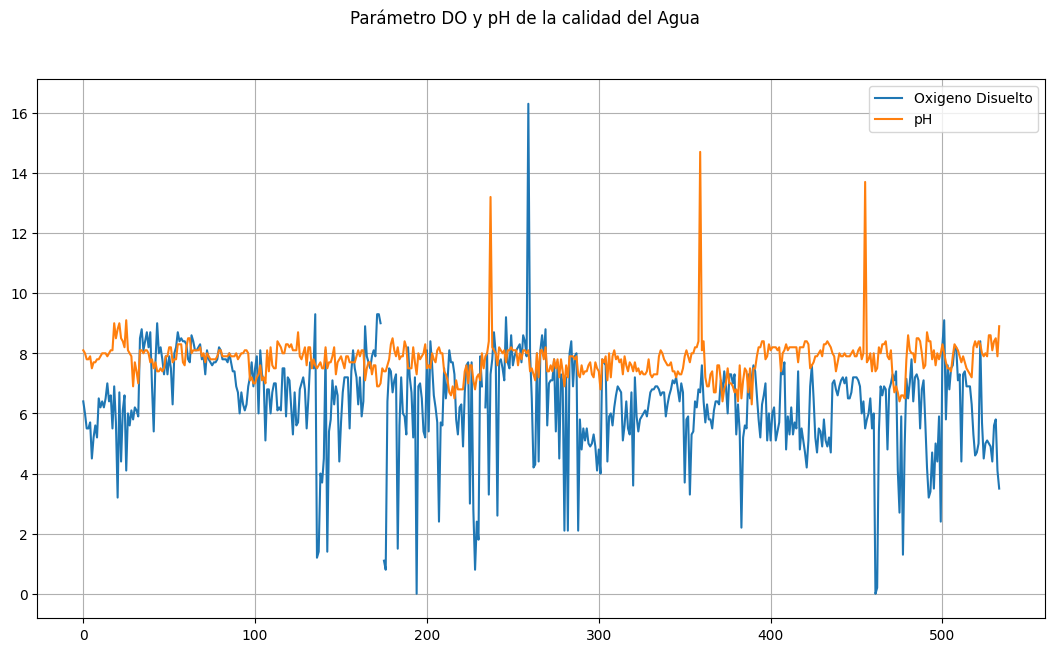

In [16]:
tam = len(do_parametro)
fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')
ax1.plot(range(0,tam), do_parametro, label='Oxigeno Disuelto')
ax1.plot(range(0,tam), ph_parametro, label='pH')
fig.suptitle('Parámetro DO y pH de la calidad del Agua')
legend=ax1.legend()
plt.grid()
plt.show()

El pH (naranja) es muy estable, rondando entre 7.5 y 8.5, que es un rango normal para agua. Existen picos que llegan hasta 13-14, siendo estos valores atípicos u outliers, probablemente errores de medición, porque un pH de 13 en agua natural es prácticamente imposible.
El Oxígeno Disuelto (azul) fluctúa bastante entre 4 y 9 mg/L, con caídas puntuales hasta casi 0. Valores por debajo de 5 mg/L ya indican estrés para la vida acuática, y los que llegan a 0 son señal de zonas con contaminación orgánica severa.

### Grafica Los parámetros para conocer sus características: BOD y Nitrogrenos


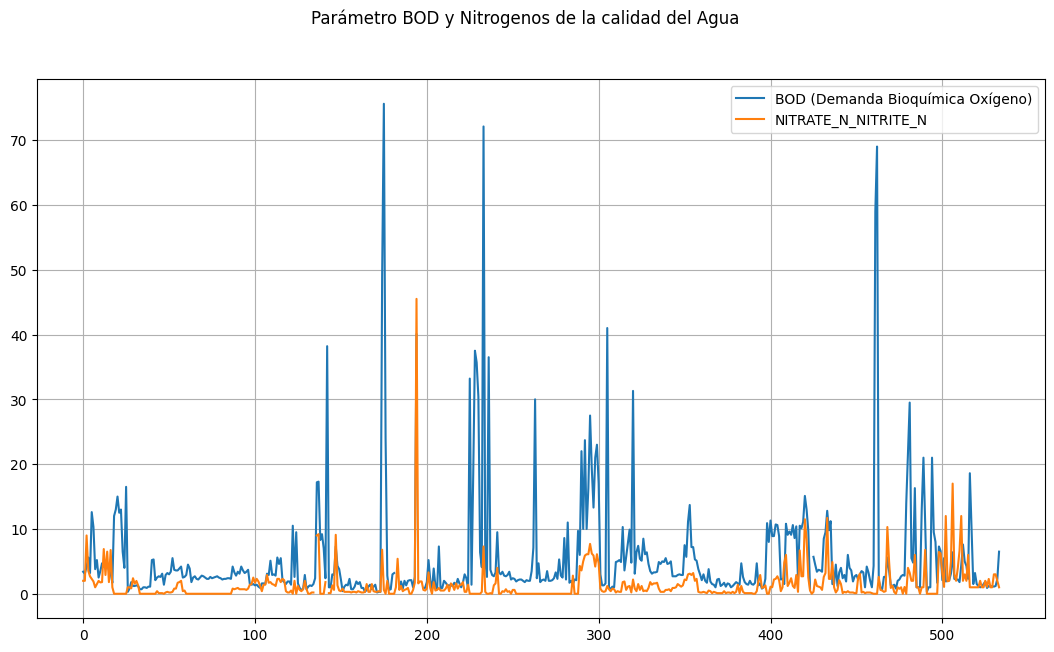

In [17]:
tam = len(do_parametro)
fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')
ax1.plot(range(0,tam), BOD_parametro, label='BOD (Demanda Bioquímica Oxígeno)')
ax1.plot(range(0,tam), NN_parametro, label='NITRATE_N_NITRITE_N')
fig.suptitle('Parámetro BOD y Nitrogenos de la calidad del Agua')
legend=ax1.legend()
plt.grid()
plt.show()

El BOD (azul) tiene picos muy agudos hasta 75, lo que indica episodios fuertes de contaminación orgánica en muestras específicas. Casi siempre se mantiene por debajo de (0-10), lo que sería aceptable.
El Nitrógeno (naranja) es por lo general bajo, con un pico importante cerca de la muestra 180 (~46), lo que podría indicar un evento de escorrentía agrícola o vertido.

### Grafica Los parámetros para conocer sus características: FC y Conductividad

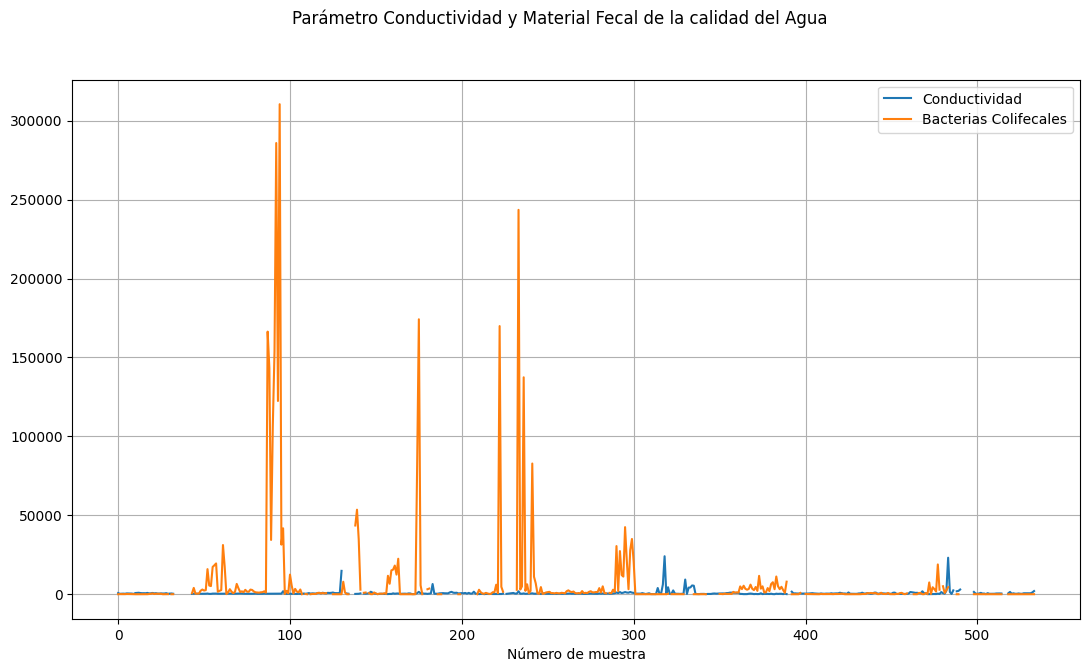

In [18]:
tam = len(do_parametro)
fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')
ax1.plot(range(0,tam), COND_parametro, label='Conductividad')
ax1.plot(range(0,tam), FC_parametro, label='Bacterias Colifecales')
fig.suptitle('Parámetro Conductividad y Material Fecal de la calidad del Agua')
legend=ax1.legend()
plt.xlabel("Número de muestra")
plt.grid()
plt.show()

Hay picos extremos de coliformes en las muestras 90–100, 230–240 y 170, que son señales críticas de contaminación fecal muy alta. Esto es un problema grave de calidad del agua.

### Función definida por el usuario para definir el rango de calidad de agua según el pH
### Se crea la columna para los rangos del parámetro (Según https://www.intechopen.com/chapters/69568)

In [19]:
# Rangos cercanos al óptimo reciben puntuaciones intermedias
# Rango óptimo, pH 7.0 - 8.5
df03 = df02.withColumn("qrPH", F.when((df02.pH>=7.0) & (df02.pH<=8.5),100).

       when(((df02.pH>=6.8) & (df02.pH<6.9)) | ((df02.pH>8.5) & (df02.pH<8.6)), 80).

       when(((df02.pH>=6.7) & (df02.pH<6.8)) | ((df02.pH>=8.6) & (df02.pH<8.8)), 60).

       when(((df02.pH>=6.5) & (df02.pH<6.7)) | ((df02.pH>=8.8) & (df02.pH<9.0)), 40).otherwise(0))

 ### Función definida por el usuario para definir el rando de la calidad del agua según el Oxigeno

In [20]:
# Oxígeno disuelto, valores altos = agua saludable para vida acuática
df03 = df03.withColumn("qrDO", F.when((df02.OXYGENO>=6.0), 100).
                      when((df02.OXYGENO>=5.1) & (df02.OXYGENO<6.0), 80).
                      when((df02.OXYGENO>=4.1) & (df02.OXYGENO<=5.0), 60).
                      when((df02.OXYGENO>=3.0) & (df02.OXYGENO<=4.0), 40).otherwise(0))

* ### Función definida por el usuario para definir el rando de la calidad del agua según la Conductividad

In [21]:
# Conductividad mide sales disueltas. Menor conductividad = mejor calidad
df03 = df03.withColumn("qrCOND", F.when(((df02.CONDUCTIVIDAD>=0.0) & (df02.CONDUCTIVIDAD<=75.0)), 100).
            when((df02.CONDUCTIVIDAD>75.0) & (df02.CONDUCTIVIDAD<=150.0), 80).
            when((df02.CONDUCTIVIDAD>150.0) & (df02.CONDUCTIVIDAD<=225.0), 60).
            when((df02.CONDUCTIVIDAD>225.0) & (df02.CONDUCTIVIDAD<=300.0), 40).otherwise(0))

* ### Función definida por el usuario para definir el rando de la calidad del agua según BOD

In [22]:
# BOD mide contaminación orgánica. Valores bajos = agua limpia
df03 = df03.withColumn("qrBOD", F.when(((df02.BOD>=0.0) & (df02.BOD<3.0)), 100).
                       when((df02.BOD>=3.0) & (df02.BOD<6.0), 80).
                       when((df02.BOD>=6.0) & (df02.BOD<80.0), 60).
                       when((df02.BOD>=80.0) & (df02.BOD<125.0), 40).otherwise(0))

* ### Función definida por el usuario para definir el rando de la calidad del agua según NITRATE_N_NITRITE_N
    * ### 100: Agua Dulce
    * ### 80: Agua Moderada
    * ### 60: Agua Dura
    * ### 40: Agua muy Dura

In [23]:
# Nitrógeno total, valores altos indican contaminación por fertilizantes/aguas residuales
df03 = df03.withColumn("qrNN", F.when(((df02.NITROGENO>=0.0) & (df02.NITROGENO<20.0)), 100).
                       when((df02.NITROGENO>=20.0) & (df02.NITROGENO<50.0), 80).
                       when((df02.NITROGENO>=50.0) & (df02.NITROGENO<100.0), 60).
                       when((df02.NITROGENO>=100.0) & (df02.NITROGENO<200.0), 40).otherwise(0))

* ### Función definida por el usuario para definir el rando de la calidad del agua según el Material Fecal
  *  ### 100: Agua Dulce
  *  ### 80: Agua Moderada
  *  ### 60: Agua Dura
  *  ### 40: Agua muy Dura


In [24]:
# Coliformes fecales: indicador de contaminación fecal
df03 = df03.withColumn("qrFecal", F.when(((df02.BACTERIAS_COLIFORMES>=0.0) & (df02.BACTERIAS_COLIFORMES<5.0)), 100).
                       when((df02.BACTERIAS_COLIFORMES>=5.0) & (df02.BACTERIAS_COLIFORMES<50.0), 80).
                       when((df02.BACTERIAS_COLIFORMES>=50.0) & (df02.BACTERIAS_COLIFORMES<500.0), 60).
                       when((df02.BACTERIAS_COLIFORMES>=500.0) & (df02.BACTERIAS_COLIFORMES<1000.0), 40).otherwise(0))

### El objeto dataframe df03, contiene hasta ahora todos los calculos y registros sobre los rangos de calidad del agua**

In [25]:
#A continuación se hace una inspección en general del df03
df03.show(10)

+------+--------------------+-----------+-----------+-------+---+-------------+----+---------+--------------------+----+----+------+-----+----+-------+
|CODIGO|         UBICACIONES|     ESTADO|TEMPERATURA|OXYGENO| pH|CONDUCTIVIDAD| BOD|NITROGENO|BACTERIAS_COLIFORMES|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal|
+------+--------------------+-----------+-----------+-------+---+-------------+----+---------+--------------------+----+----+------+-----+----+-------+
|  1312|GODAVARI AT JAYAK...|MAHARASHTRA|       29.2|    6.4|8.1|        735.0| 3.4|      2.0|                 3.0| 100| 100|     0|   80| 100|    100|
|  2177|GODAVARI RIVER NE...|MAHARASHTRA|       24.5|    6.0|8.0|        270.0| 3.1|      2.0|                72.0| 100| 100|    40|   80| 100|     60|
|  2182|GODAVARI RIVER AT...|MAHARASHTRA|       25.8|    5.5|7.8|        355.0| 4.2|      9.0|                59.0| 100|  80|     0|   80| 100|     60|
|  2179|GODAVARI RIVER AT...|MAHARASHTRA|       24.8|    5.5|7.8|        371.0| 5.6|    

In [26]:
 ##Nombre de Columnas
df03.columns

['CODIGO',
 'UBICACIONES',
 'ESTADO',
 'TEMPERATURA',
 'OXYGENO',
 'pH',
 'CONDUCTIVIDAD',
 'BOD',
 'NITROGENO',
 'BACTERIAS_COLIFORMES',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal']

## **Creación de columnas que contengan el Índice de Calidad según la refencia bibliográfica**
### Se crea un nuevo objeto dataframe con las nuevas columnas de Indice de Calidad

In [27]:
# Cada peso representa la importancia relativa del parámetro en el índice WQI
df04 = df03.withColumn("wpH", F.round(df03.qrPH*0.165,3))
df04 = df04.withColumn("wDO", F.round(df04.qrDO*0.281,3))
df04 = df04.withColumn("wCOND", F.round(df04.qrCOND*0.234,3))
df04 = df04.withColumn("wBOD", F.round(df04.qrBOD*0.009,3))
df04 = df04.withColumn("wNN", F.round(df04.qrNN*0.028,3))
df04 = df04.withColumn("wFecal", F.round(df04.qrFecal*0.281,3))

In [28]:
df04.show(10)

+------+--------------------+-----------+-----------+-------+---+-------------+----+---------+--------------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+
|CODIGO|         UBICACIONES|     ESTADO|TEMPERATURA|OXYGENO| pH|CONDUCTIVIDAD| BOD|NITROGENO|BACTERIAS_COLIFORMES|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|
+------+--------------------+-----------+-----------+-------+---+-------------+----+---------+--------------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+
|  1312|GODAVARI AT JAYAK...|MAHARASHTRA|       29.2|    6.4|8.1|        735.0| 3.4|      2.0|                 3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|
|  2177|GODAVARI RIVER NE...|MAHARASHTRA|       24.5|    6.0|8.0|        270.0| 3.1|      2.0|                72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|
|  2182|GODAVARI RIVER AT...|MAHARASHTRA|       25.8|    5.5|7.8|        35

In [29]:
df04.columns

['CODIGO',
 'UBICACIONES',
 'ESTADO',
 'TEMPERATURA',
 'OXYGENO',
 'pH',
 'CONDUCTIVIDAD',
 'BOD',
 'NITROGENO',
 'BACTERIAS_COLIFORMES',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal',
 'wpH',
 'wDO',
 'wCOND',
 'wBOD',
 'wNN',
 'wFecal']

### **Calculo del Índice de Calidad del Agua**

   - Se crea la columna WQI: representa el índice de calidad, pero la NOTA A RESALTAR es que según la literatura, son muy pocos datos para que refleje un valor confiable. Es decir, que como un estudio ejemplo, NO ES UNA GUIA A TENER EN CUENTA PARA CALIDAD DE AGUA

In [30]:
#Se Calcula el WQI sumando todos los componentes ponderados
df05 = df04.withColumn("WQI", F.round(df04.wpH+df04.wBOD+df04.wCOND+df04.wNN+df04.wFecal+df04.wDO,3))
df05.show(10)

+------+--------------------+-----------+-----------+-------+---+-------------+----+---------+--------------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+
|CODIGO|         UBICACIONES|     ESTADO|TEMPERATURA|OXYGENO| pH|CONDUCTIVIDAD| BOD|NITROGENO|BACTERIAS_COLIFORMES|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI|
+------+--------------------+-----------+-----------+-------+---+-------------+----+---------+--------------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+
|  1312|GODAVARI AT JAYAK...|MAHARASHTRA|       29.2|    6.4|8.1|        735.0| 3.4|      2.0|                 3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|76.22|
|  2177|GODAVARI RIVER NE...|MAHARASHTRA|       24.5|    6.0|8.0|        270.0| 3.1|      2.0|                72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|74.34|
|  2182|GODAVARI RIVER AT...|MAHARASHTRA|    

**Intervalos de Índices para WQI**

- Excelente: agua dulce ***WQI = [0.0 , 25.0]***
- Buena: agua moderada ***WQI = (25.0 , 50.0]***
- Baja: agua dura ***WQI = (50.0 , 75.0]***
- Muy_Baja: agua muy dura ***WQI = (75.0 , 100.0]***
- Inadecuada: agua residual ***WQI > 100***

In [31]:
# Se Clasifica la calidad del agua segun el WQI calculado
df06 = df05.withColumn("CALIDAD",
    F.when((df05.WQI >= 75) & (df05.WQI <= 100), 'Excelente')
    .when((df05.WQI >= 50) & (df05.WQI < 75),   'Buena')
    .when((df05.WQI >= 25) & (df05.WQI < 50),   'Baja')
    .when((df05.WQI >= 0)  & (df05.WQI < 25),   'Muy_Baja')
    .otherwise('Inadecuada'))

In [32]:
df06.show(10)

+------+--------------------+-----------+-----------+-------+---+-------------+----+---------+--------------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+---------+
|CODIGO|         UBICACIONES|     ESTADO|TEMPERATURA|OXYGENO| pH|CONDUCTIVIDAD| BOD|NITROGENO|BACTERIAS_COLIFORMES|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI|  CALIDAD|
+------+--------------------+-----------+-----------+-------+---+-------------+----+---------+--------------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+---------+
|  1312|GODAVARI AT JAYAK...|MAHARASHTRA|       29.2|    6.4|8.1|        735.0| 3.4|      2.0|                 3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|76.22|Excelente|
|  2177|GODAVARI RIVER NE...|MAHARASHTRA|       24.5|    6.0|8.0|        270.0| 3.1|      2.0|                72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|74.34|    Bu

Al analizar las 10 primeras filas de la tabla, es posible confirmar que la lógica del índice WQI está funcionando de manera correcta. El caso de la primera fila es interesante ya que a pesar de tener una conductividad muy alta (735) con una puntuación de 0 en este parámetro, el excelente desempeño en DO, pH, BOD, nitrógeno y coliformes bajas logra mantener un WQI de 76.22, clasificándola como Excelente. En contraste, la fila 6 muestra una zona con DO bajo (4.5), conductividad alta (513), BOD de 12.6 y coliformes de 131, lo que arastra el WQI a 53.56 y la califica como Buena, una categoría que podría ser discutida dado que varios parámetros están en zona de alerta, pero que el modelo justifica por el alto peso asignado al DO y al pH, ambos parámetros que aún puntúan bien en esa muestra.
La última fila, correspondiente a la estación GODAVARI AT U/S, con conductividad moderada (178), DO de 6.5, pH de 7.8, BOD bajo (2.5) y coliformes reducidas (22), es el caso más representativo de agua en buen estado, obteniendo el WQI más alto de las 10 muestras con 84.82 puntos. 
Esto indica que el índice responde de manera coherente a la combinación de parámetros, penalizando fuertemente cuando los indicadores biológicos y de oxígeno fallan, y recompensando cuando la mayoría de variables se encuentran dentro de los rangos óptimos establecidos.

In [33]:
#Se cuentan cuántas muestras caen en cada categoría
df06.groupBy("CALIDAD").count().show()


+---------+-----+
|  CALIDAD|count|
+---------+-----+
|Excelente|   69|
|    Buena|  271|
| Muy_Baja|   25|
|     Baja|  169|
+---------+-----+



Se considera que un 63,6% del agua es aceptable, esto incluye la categoría Excelente y  Buena) destacando la categoría Buena con la mitad de las muestras.
El 36.3% restante es de calidad Baja o Muy Baja, lo cual es preocupante si se consideran los picos de coliformes que se observaron en la gráfica 3, que eran extremadamente altos.
Ninguna de las muestras cae dentro de la categoría "Inadecuada", lo cual puede deberse al bajo peso del BOD (0.9%) lo que hace que incluso las muestras con BOD alto no disminuyan el WQI lo suficiente.
El parámetro que más “protege” al índice es el pH, que se observo desde la grafica 1 que era astante estable, teniendo un peso del 16.5 %.

### **VISUALIZACIÓN DE ESTADOS DE LA INDIA**

- Se visualizan los estados sobre los datos obtenidos de la Calidad del Agua, es decir, las etiquetas de calidad de agua

- Impresión de nombre de regiones sobre el mapa


In [34]:
# Extrae los valores únicos de la columna ESTADO para conocer qué estados están presentes en el dataset
colEstado = 'ESTADO'
valNomnbres = df06.select(colEstado).distinct().collect()
valNomnbres = [v[colEstado] for v in valNomnbres]

print(valNomnbres)

['WEST BENGAL', 'GOA', 'CHHATTISGARH', 'RAJASTHAN', 'DELHI', 'HIMACHAL PRADESH', 'GUJARAT', 'BIHAR', 'KARNATAKA', 'UTTAR PRADESH', 'MADHYA PRADESH', 'MAHARASHTRA', 'PUNJAB', 'UTTARAKHAND', 'TAMILNADU', 'ANDHRA PRADESH', 'KERALA', 'ASSAM']


#### **Se cargan los datos de los mapas disponibles**

- Los ficheros comprimidos "dbf", "prj", "shp", "shx" deben estar juntos en una carpeta

In [ ]:
#pip install geopandas
#

In [35]:
# Carga el shapefile con la geometría de los estados de India
import geopandas as gpd
rutaMapas = "Indian_States/Indian_States.shp"
## Se carga un objeto dataframe de los datos comprimidos de los mapas
gpd01 = gpd.read_file(rutaMapas)

## Se visualiza el tipo de dataframe que da geopandas y las columnas 

print(type(gpd01))

gpd01.columns


#Se visualizan los nombres de la columna de los estados "st_nm"
gpd01["st_nm"].unique()

<class 'geopandas.geodataframe.GeoDataFrame'>


array(['Andaman & Nicobar Island', 'Arunanchal Pradesh', 'Assam', 'Bihar',
       'Chandigarh', 'Chhattisgarh', 'Dadara & Nagar Havelli',
       'Daman & Diu', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh',
       'Jammu & Kashmir', 'Jharkhand', 'Karnataka', 'Kerala',
       'Lakshadweep', 'Madhya Pradesh', 'Maharashtra', 'Manipur',
       'Meghalaya', 'Mizoram', 'Nagaland', 'NCT of Delhi', 'Puducherry',
       'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana',
       'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal', 'Odisha',
       'Andhra Pradesh'], dtype=object)

In [36]:
### Se procede a eliminar caracteres irregulares: la idea es que los estados del mapa coincidan 
### con los nombres de los estados del dataframe de datos inicial
## Estandarización de nombres en el shapefile: se eliminan los '&'
#para que coincidan con los nombres del DataFrame de Spark
gpd02 = gpd01.replace({'Andaman & Nicobar Island': 'Andaman Nicobar Island',
                      'Dadara & Nagar Havelli': 'Dadara Nagar Havelli',
                     'Daman & Diu': 'Daman Diu', 
                      'Jammu & Kashmir': 'Jammu Kashmir',
                      'NCT of Delhi' : 'Delhi'
                      })
gpd02["st_nm"].unique()

array(['Andaman Nicobar Island', 'Arunanchal Pradesh', 'Assam', 'Bihar',
       'Chandigarh', 'Chhattisgarh', 'Dadara Nagar Havelli', 'Daman Diu',
       'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu Kashmir',
       'Jharkhand', 'Karnataka', 'Kerala', 'Lakshadweep',
       'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram',
       'Nagaland', 'Delhi', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim',
       'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh',
       'Uttarakhand', 'West Bengal', 'Odisha', 'Andhra Pradesh'],
      dtype=object)

Se hacen los cambios correspondientes, a continuación, para que coincidan con los nombres iniciales
- nombre de "st_nm" que sea "STATE"
- Se combinan es formato pandas para pintar el mapa
- Se garantizan los puntos dentro del mapa
- Se eliminan los duplicados

In [44]:
#Nombre de "Tamil Nadu" se cambia a "TAMILNADU" en objeto dataframe spark
df07 = df06.withColumn('ESTADO', F.regexp_replace('ESTADO', 'TAMILNADU', 'TAMIL NADU'))

#Se deja todo en letra Capital en el df spark
df07 = df07.withColumn('ESTADO', F.initcap('ESTADO'))

#Inspección ocular del cambio
df07.show(5)

+------+--------------------+-----------+-----------+-------+---+-------------+---+---------+--------------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+---------+
|CODIGO|         UBICACIONES|     ESTADO|TEMPERATURA|OXYGENO| pH|CONDUCTIVIDAD|BOD|NITROGENO|BACTERIAS_COLIFORMES|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI|  CALIDAD|
+------+--------------------+-----------+-----------+-------+---+-------------+---+---------+--------------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+---------+
|  1312|GODAVARI AT JAYAK...|Maharashtra|       29.2|    6.4|8.1|        735.0|3.4|      2.0|                 3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|76.22|Excelente|
|  2177|GODAVARI RIVER NE...|Maharashtra|       24.5|    6.0|8.0|        270.0|3.1|      2.0|                72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|74.34|    Buena|


In [46]:
#Se cambia el nombre en el gpd de la columna "st_nm" a "STATE"
gpd03 = gpd02.rename(columns= {"st_nm": "ESTADO"})

#Se combinan los nombres entre los dos objetos dataframe: map y spark, con la clave "STATE"
dfMAP = pd.merge(gpd03, df07.toPandas(), how='outer', on='ESTADO')

#Se toman los puntos a bajo coste que garantizan estar dentro de la geometria (mapa)
dfMAP['coords'] = dfMAP['geometry'].apply(lambda x: x.representative_point().coords[:])
dfMAP['coords'] = [coords[0] for coords in dfMAP['coords']]

#Se eliminan los puntos duplicados
dfMAP = dfMAP.drop_duplicates(subset="ESTADO")

### **Se pinta el mapa inicial**

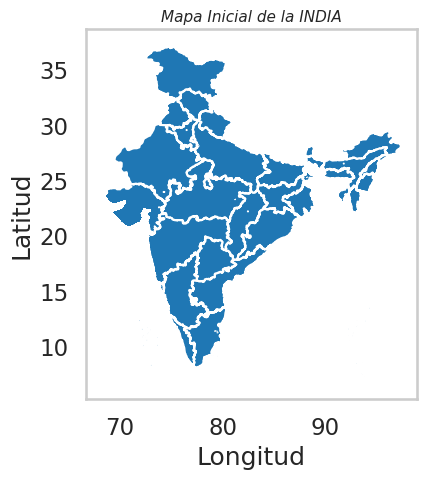

In [47]:
# Mapa base inicial solo para verificar que la geometría cargó correctamente
dfMAP.plot(missing_kwds={'color': 'lightgrey'})
plt.title("Mapa Inicial de la INDIA", fontsize=11, style='italic')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid()
plt.show()

#### *-Se requiere superponer las etiquetas de los estados de la India en el MAPA*

In [48]:
# Instalación de librerías necesarias para el mapa final
import sys
!{sys.executable} -m pip install adjustText
!{sys.executable} -m pip install "mapclassify >= 2.4.0"

from adjustText import adjust_text #Para evitar que se supermonten las etiquetas

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


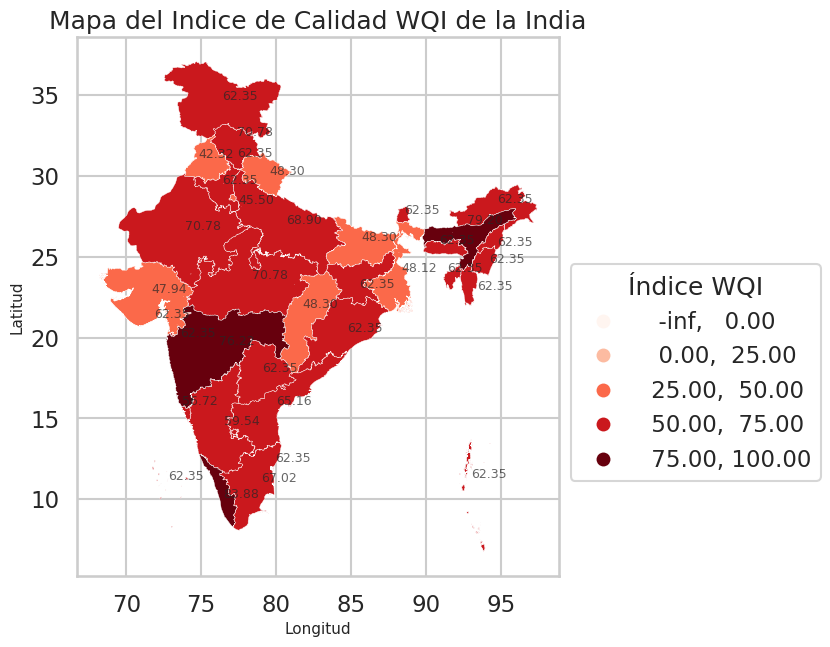

In [49]:
#Se verifica los valores NULOS; en caso de que existan se cambian por el promedio
#Se toma la ruta corta (la imputación de valores nulos puede ser mejor tratada)
dfMAP['WQI'] = dfMAP['WQI'].fillna(dfMAP['WQI'].median())

## Configuración de Estilos para ser usados en la impresión con seaborn
sns.set_context("talk") #puede ser cualquiera
sns.set_style("whitegrid") #Puede ser cualquiera de la biblioteca de estilos de seaborn

#Se ajusta el mapa 
fig, ax = plt.subplots(figsize = (12,7))
#dibujar el mapa
dfMAP.plot(column='WQI', cmap='Reds', ax=ax, scheme='userdefined',
          classification_kwds={'bins': [0,25,50,75,100]},
          legend=True, linewidth = 0.3)

##Ajustar la leyenda
leg = ax.get_legend()
leg.set_title('Índice WQI')
leg.set_bbox_to_anchor((1,0.6))

## Se agregan las etiquetas sin superposición (tener cuidado con el tamaño del PLOT)
textos = []
for _, row in dfMAP.iterrows():
    if not np.isnan(row['WQI']):
        centroide = row.geometry.centroid
        texto = ax.annotate(f"{row['WQI']:.2f}", xy=(centroide.x, centroide.y),
                           fontsize=9, alpha=0.7)
        textos.append(texto)
    
#Ajustar texto de etiquetas
adjust_text(textos, ax=ax, force_points=(0.2, 0.2))

### CARPINTERIA
ax.set_title("Mapa del Indice de Calidad WQI de la India")
ax.set_xlabel("Longitud", fontsize=11)
ax.set_ylabel("Latitud", fontsize=11)
plt.show()

El mapa indica que la mayor parte del territorio indio se encuentra en el rango de WQI entre 50 y 75, representado en rojo medio, que corresponde a la categoría “Buena”. Esto concuerda con los resultados del groupBy donde el 50.7% de las muestras pertenecían a la categoría dominante, “Buena”.
Sólo uno de los estados del sur del país alcanza el rango oscuro de 75 a 100, probablemente Kerala o Tamil Nadu, lo que indicaría las mejores condiciones de calidad del agua en esa zona. El estado en naranja claro que está al oeste, con un WQI de 47.94, posiblemente Gujarat o Rajasthan, tiene las peores condiciones de todo el mapa.


### **Histograma de WQI por Estado**

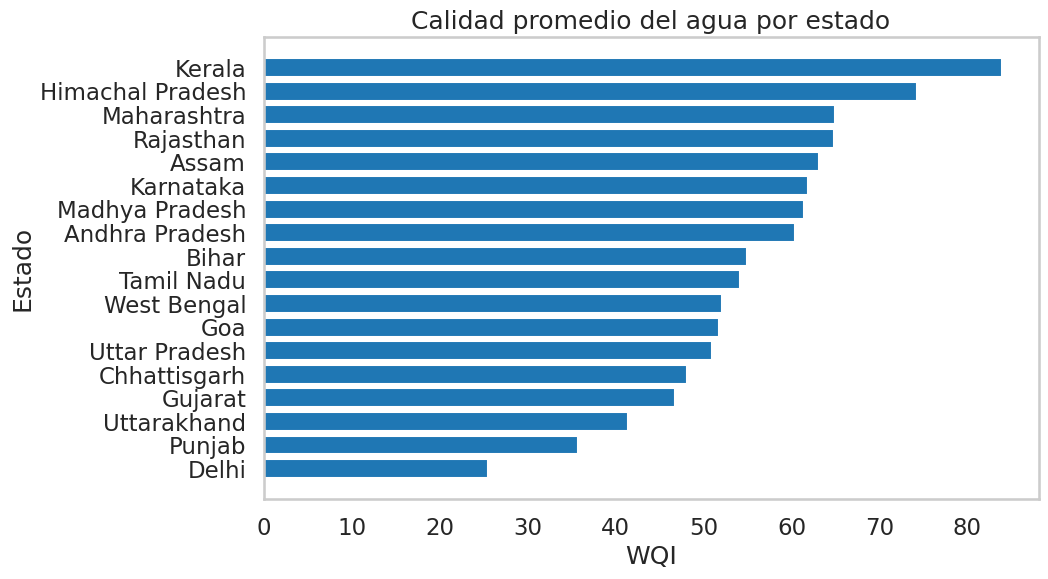

In [51]:
# Registrar df07 como vista temporal para poder consultarla con SQL
df07.createOrReplaceTempView("df07_sql")

df_estado = sparkS.sql("""
SELECT ESTADO, AVG(WQI) as WQI_promedio
FROM df07_sql
GROUP BY ESTADO
""")

pdf = df_estado.toPandas()
pdf = pdf.sort_values("WQI_promedio")

plt.figure(figsize=(10,6))
plt.barh(pdf["ESTADO"], pdf["WQI_promedio"])
plt.title("Calidad promedio del agua por estado")
plt.xlabel("WQI")
plt.ylabel("Estado")
plt.grid()
plt.show()

* En primer lugar esta Kerala, con un WQI medio de cerca del 83, el único estado que alcanza la categoría “Excelente” en la escala corregida, lo cual coincide con lo que se veía en el mapa, donde el sur del país aparecía en un tono más oscuro. Le sigue Himachal Pradesh con aproximadamente 74, también rozando la categoría Excelente. Los dos estados con mejores condiciones de calidad del agua del dataset son estados con menor densidad industrial en zonas montañosas.
* Desde Maharashtra hasta West Bengal, la mayoría de los estados se agrupan en el rango de 50 a 65, que se clasifica como “Buena”, la condición típica del agua en India por estas mediciones. Es un rango aceptable pero con margen de mejora, especialmente en parámetros como el de coliformes y la conductividad.
* Los casos más preocupantes son los de Delhi, Punjab y Uttarakhand, que están por debajo de los 45. En el caso de Delhi, con un WQI cercano a 25, el nivel está en la frontera entre “Baja” y “Muy Baja”, lo cual es comprensible si se tiene en cuenta que se trata de la capital con alta densidad poblacional, presión industrial y problemas históricos de contaminación del río Yamuna. Es posible que Punjab muestre también el impacto de la intensa actividad agrícola con uso de fertilizantes, lo que eleva los niveles de nitrógeno y de coliformes.

### **Creación de Modelo: Calidad de Agua en la India**

    - Se requiere predecir el parámetro WQI
    - Se crea un DF en pandas, un vector para manipular a través de numpy las columnas de calidad: "Rangos de Calidad" 
    - Se importa Scikit-Learn, para separar los datos (Entrenamiento y Prueba)
    - Se importa Keras Sequential Layers Dense
    - Se inicializa el modelo, y se añaden las capas
    - Se compila el modelo con el optimizador ADAM junto con la función de perdida de error cuadrático
    - Se realiza el experimento sobre los datos de entrenamiento
    - Se realiza la evaluación sobre los datos de prueba; para la selección del modelo.

In [52]:
df07.columns

['CODIGO',
 'UBICACIONES',
 'ESTADO',
 'TEMPERATURA',
 'OXYGENO',
 'pH',
 'CONDUCTIVIDAD',
 'BOD',
 'NITROGENO',
 'BACTERIAS_COLIFORMES',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal',
 'wpH',
 'wDO',
 'wCOND',
 'wBOD',
 'wNN',
 'wFecal',
 'WQI',
 'CALIDAD']

In [53]:
#- Se requiere predecir el parámetro WQI
#- Se crea un DF en pandas, un vector para manipular a través de numpy las columnas de calidad: "Rangos de Calidad"

dfcalidad = df07.select('qrPH','qrDO','qrCOND','qrBOD','qrNN','qrFecal')
dfPredecir = df07.select('WQI')

dfcalidad.show(5)
dfPredecir.show(5)

+----+----+------+-----+----+-------+
|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal|
+----+----+------+-----+----+-------+
| 100| 100|     0|   80| 100|    100|
| 100| 100|    40|   80| 100|     60|
| 100|  80|     0|   80| 100|     60|
| 100|  80|     0|   80| 100|     60|
| 100|  80|    40|   80| 100|     80|
+----+----+------+-----+----+-------+
only showing top 5 rows

+-----+
|  WQI|
+-----+
|76.22|
|74.34|
|59.36|
|59.36|
|74.34|
+-----+
only showing top 5 rows



In [54]:
#- Se crea un DF en pandas, un vector para manipular a través de numpy las columnas de calidad: "Rangos de Calidad" 
#- Se importa Scikit-Learn, para separar los datos (Entrenamiento: 80% y Prueba: 20%)

from sklearn.model_selection import train_test_split

dataTrain, dataTest, predTrain, predTest = train_test_split(dfcalidad.toPandas(), dfPredecir.toPandas(), test_size=0.2, random_state=1)

In [55]:
print(f"Cantidad de datos totales: {df07.count(), len(df07.columns)}")
print(f"Cantidad de datos Entrenamiento: {dataTrain.shape}")
print(f"Cantidad de datos Prueba: {dataTest.shape}")
print(f"Cantidad de datos Predicción del Entrenamiento: {predTrain.shape}")
print(f"Cantidad de datos Predicción de Prueba: {predTest.shape}")

Cantidad de datos totales: (534, 24)
Cantidad de datos Entrenamiento: (427, 6)
Cantidad de datos Prueba: (107, 6)
Cantidad de datos Predicción del Entrenamiento: (427, 1)
Cantidad de datos Predicción de Prueba: (107, 1)


* Los datos que se incorporan al modelo de predicción están preparados de una manera correcta y bien organizada. Las variables independientes fueron definidas como los seis puntajes de calidad por parámetro (qrPH, qrDO, qrCOND, qrBOD, qrNN y qrFecal) y la variable dependiente como el WQI final. La proporción 80/20 para entrenamiento y prueba es una proporción estándar y apropiada para el tamaño del dataset, y el uso de random_state=1 asegura que los resultados sean repetibles en cualquier ejecución posterior.

* Sin embargo, en un contexto de análisis real seria necesario usar como features los valores físicos originales como temperatura, pH medido o conductividad, de tal forma que el modelo tenga que aprender una relación no trivial con el índice de calidad.

  

In [56]:
pip install keras

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [57]:
pip install tensorflow


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [107]:
## Se importa la instancia TensorFlow
import keras
from keras.models import Sequential
from keras.layers import Dense

In [108]:
modelo01 = Sequential()
modelo01.add(Input(shape=(6,)))
modelo01.add(Dense(64, activation='relu'))
modelo01.add(Dense(32, activation='relu'))
modelo01.add(Dense(1, activation='linear')) 

modelo01.compile(
    loss='mean_squared_error',
    optimizer='Adam',
    metrics=['mse']
)


* Se desarrolló un modelo de red neuronal secuencial orientado a resolver un problema de regresión, con el fin de predecir el índice de calidad del agua (WQI) a partir de seis variables de entrada. La arquitectura del modelo comienza con una capa de entrada definida mediante Input(shape=(6,)), lo cual representa que cada observación está constituida por seis características.
  
* Posteriormente, se añaden dos capas ocultas densas: la primera de 64 neuronas y la segunda de 32 neuronas, ambas con la función de activación ReLU (Rectified Linear Unit), que permite capturar relaciones no lineales entre las variables y mejorar la capacidad de aprendizaje del modelo. Por último, se utiliza una capa de salida con una única neurona y función de activación lineal, lo cual resulta adecuado para problemas de regresión en los que se quiere predecir un valor continuo.

* El algoritmo Adam, por su eficacia en el ajuste de parámetros, se utilizó para la optimización del modelo, combinado con la función de pérdida de error cuadrático medio (Mean Squared Error), adecuada para medir la diferencia entre los valores reales y los estimados en problemas de esta índole. También se incluyó la métrica MSE como medida de desempeño durante el entrenamiento.
  

In [109]:
modelo01.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,561 (10.00 KB)

 Trainable params: 2,561 (10.00 KB)

 Non-trainable params: 0 (0.00 B)

* Esta es la estructura final del modelo, que está formado por tres capas densas. La primera capa tiene 64 neuronas y toma las 6 variables de entrada, luego tiene una capa oculta de 32 neuronas que permite capturar patrones más complejos en los datos. Por último, la capa de salida consta de 5 neuronas, que corresponden a las clases de calidad del agua. El modelo tiene un total de 2,693 parámetros entrenables, lo que refleja una arquitectura ligera y eficiente, apropiada al tamaño del conjunto de datos y capaz de evitar problemas de sobreajuste.

In [110]:
ejecutarK = modelo01.fit(dataTrain, predTrain, epochs=epocas, batch_size=lote)

Epoch 1/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 4976.4004 - mse: 4976.4004 
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2258.3147 - mse: 2258.3147 
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 810.0449 - mse: 810.0449  
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 171.7873 - mse: 171.7873
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 125.7595 - mse: 125.7594
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 191.0379 - mse: 191.0379
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 135.6960 - mse: 135.6960
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 82.1259 - mse: 82.1259
Epoch 9/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 66.0515 - mse: 66.0515
Epoch 10/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 63.7352 - mse: 63.7352
Epoch 11/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 58.7251 - mse: 58.7251
Epoch 12/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 43.4745 - mse: 43.4745
Epoc

In [111]:
print(dataTrain.shape)


(427, 6)


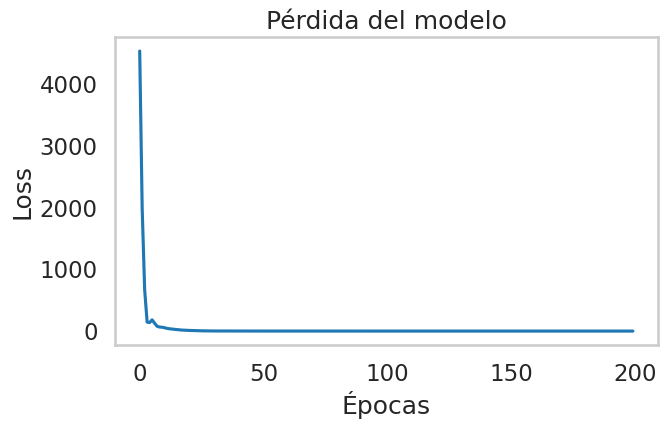

In [112]:
plt.figure(figsize=(7,4))
plt.plot(ejecutarK.history['loss'])
plt.title("Pérdida del modelo")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.grid()
plt.show()


* La curva de pérdida muestra una caída rápida y pronunciada en las primeras épocas, para después estabilizarse, prácticamente a cero. Esto demuestra que el modelo es capaz de aprender de forma eficaz los patrones existentes en los datos y de alcanzar una convergencia satisfactoria, lo cual pone en evidencia un proceso de entrenamiento exitoso.

In [113]:
### Se requiere predecir sobre los datos del entrenamiento
predModelo01_Train = modelo01.predict(dataTrain)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


In [114]:
print(predTrain.shape)
print(predModelo01_Train.shape)


(427, 1)
(427, 1)


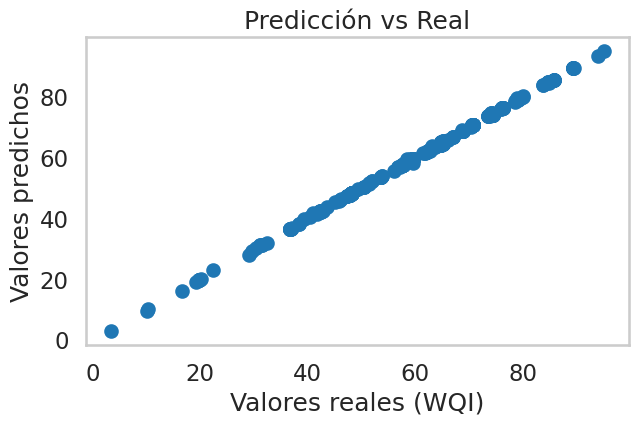

In [115]:
plt.figure(figsize=(7,4))

plt.scatter(predTrain, predModelo01_Train.flatten())

plt.xlabel("Valores reales (WQI)")
plt.ylabel("Valores predichos")
plt.title("Predicción vs Real")

plt.grid()
plt.show()


* La comparación entre los valores reales y los valores predichos muestra una alineación casi perfecta, lo que indica que el modelo tiene una alta precisión en la estimación del índice de calidad del agua (WQI). Este comportamiento muestra una gran capacidad predictiva sobre los datos de entrenamiento.



### CONCLUSIÓN

Para este trabajo se desarrolló e implementó un pipeline completo de análisis y predicción de calidad del agua en la India, integrando herramientas de procesamiento distribuido con Apache Spark, análisis geoespacial con GeoPandas y modelado predictivo con redes neuronales mediante TensorFlow y Keras. El objetivo principal consistió en la construcción y predicción del Índice de Calidad del Agua (WQI) a partir de seis variables fisico químicas y microbiológicas: pH, oxígeno disuelto, conductividad eléctrica, demanda bioquímica de oxígeno, nitrógeno total y bacterias coliformes fecales.

En la fase de exploración y preprocesamiento se han podido identificar patrones relevantes en los datos. El pH resultó ser el parámetro más estable en todas las muestras, manteniéndose dentro de rangos aceptables para la vida acuática en la mayoría de los casos, mientras que el oxígeno disuelto tuvo caídas puntuales críticas cercanas a cero, señalando zonas con contaminación orgánica grave. Las bacterias coliformes fecales se mostraron como el parámetro más inestable, con picos extraordinarios que sobrepasaron los 300.000 UFC, señalando serios episodios de contaminación fecal en estaciones específicas. Por su parte, la conductividad presentó valores elevados en varios estados, lo cual indica que podría haber una concentración alta de sales disueltas posiblemente relacionada con la actividad agrícola o industrial.

La construcción del WQI mediante un sistema de puntuación ponderada permitió clasificar el 63,6 % de las muestras en categorías aceptables, siendo “Buena” la categoría dominante con el 50,7 % de los registros. El estudio geográfico arrojó grandes diferencias entre estados, Los mejores índices promedio fueron presentados por Kerala e Himachal Pradesh con más de 74 puntos, mientras que los valores más bajos fueron de Delhi y Punjab, con WQI de casi 25 y 35 respectivamente, reflejando el impacto de la alta densidad poblacional, la presión industrial y el uso intensivo de fertilizantes agrícolas sobre la calidad del recurso hídrico.

Los resultados obtenidos en el modelo predictivo muestran que el modelo tiene un desempeño sobresaliente, con una rápida convergencia durante el entrenamiento y una alta precisión en la predicción de los valores del WQI. Esto se explica en parte porque los puntajes intermedios, que se calculan directamente a partir de los parámetros originales, constituyen las variables de entrada, de modo que el modelo aprende una relación matemáticamente cercana a la fórmula del índice. Si se buscara realizar un paso posterior, se deberia entrenar el modelo directamente sobre los valores originales de cada parámetro, ademas de incorporar variables adicionales,  lo que obligaría a la red a descubrir relaciones no lineales más complejas y permitiría evaluar su verdadera capacidad de generalización.

En conclusión, este trabajo demuestra que la combinación de tecnologías de procesamiento distribuido, análisis geoespacial y aprendizaje profundo constituye un enfoque robusto y escalable para el monitoreo de la calidad del agua a gran escala. Desde la ingesta y limpieza de datos en Spark, hasta la construcción del índice WQI y su predicción mediante redes neuronales, puede ser adaptado a otros contextos geográficos y tipos de cuerpos de agua, convirtiéndose en una herramienta valiosa para organismos gubernamentales, instituciones ambientales y tomadores de decisiones que requieran información oportuna y confiable sobre el estado del recurso hídrico. La calidad del agua constituye un problema de salud pública a nivel mundial, y el desarrollo de modelos predictivos accesibles y replicables es un gran paso hacia un manejo más eficiente y sostenible.

